<a href="https://colab.research.google.com/github/RoshnaGeorge/ML/blob/main/Lab02_A7_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A7: Heatmap Plot for Similarity Measures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the thyroid dataset
thyroid_data = pd.read_excel(
    "Lab Session Data.xlsx",
    sheet_name="thyroid0387_UCI"
)

# Select the first 20 observations
first_20 = thyroid_data.iloc[:20].copy()

print("Shape of first 20 observations:", first_20.shape)

Shape of first 20 observations: (20, 31)


prep of binary attributes for JC,SMC

In [2]:
# Identify binary attributes
binary_columns = []

for column in thyroid_data.columns:
    unique_values = set(thyroid_data[column].dropna().unique())

    if unique_values.issubset({'t', 'f'}) and len(unique_values) > 0:
        binary_columns.append(column)

# Select binary attributes for first 20 observations
binary_data = first_20[binary_columns].replace({'t': 1, 'f': 0})

# Convert to NumPy array
binary_vectors = binary_data.to_numpy()

print("Number of Binary Attributes:", len(binary_columns))
print("Shape of Binary Data:", binary_vectors.shape)

Number of Binary Attributes: 20
Shape of Binary Data: (20, 20)


/tmp/ipykernel_1093/411321450.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  binary_data = first_20[binary_columns].replace({'t': 1, 'f': 0})


calc of pairwise JC,SMC

In [3]:
# Number of observations
n = 20

# Create empty similarity matrices
jc_matrix = np.zeros((n, n))
smc_matrix = np.zeros((n, n))

# Calculate pairwise JC and SMC
for i in range(n):
    for j in range(n):

        vector1 = binary_vectors[i]
        vector2 = binary_vectors[j]

        f11 = np.sum((vector1 == 1) & (vector2 == 1))
        f00 = np.sum((vector1 == 0) & (vector2 == 0))
        f01 = np.sum((vector1 == 0) & (vector2 == 1))
        f10 = np.sum((vector1 == 1) & (vector2 == 0))

        # Jaccard Coefficient
        denominator_jc = f01 + f10 + f11

        if denominator_jc != 0:
            jc_matrix[i, j] = f11 / denominator_jc
        else:
            jc_matrix[i, j] = 1.0

        # Simple Matching Coefficient
        smc_matrix[i, j] = (
            (f11 + f00) /
            (f00 + f01 + f10 + f11)
        )

print("JC Matrix:")
print(jc_matrix)

print("\nSMC Matrix:")
print(smc_matrix)

JC Matrix:
[[1.         0.25       0.         0.         0.         0.
  0.         0.25       0.25       0.25       0.25       0.25
  0.33333333 0.25       0.         0.5        0.25       0.
  0.14285714 0.28571429]
 [0.25       1.         0.         0.         0.         0.
  0.         1.         1.         1.         1.         1.
  0.25       1.         0.25       0.33333333 1.         0.66666667
  0.28571429 0.42857143]
 [0.         0.         1.         0.5        0.5        0.5
  0.5        0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.125     ]
 [0.         0.         0.5        1.         1.         1.
  1.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.5        1.         1.         1.
  1.         0.         0.         0.         0.         0.
  0.         0.         0.         0. 

cosine similarity

In [4]:
# Replace '?' with missing values
cosine_data = first_20.replace('?', np.nan)

# Convert categorical attributes using One-Hot Encoding
cosine_data = pd.get_dummies(cosine_data, dummy_na=True)

# Convert all data to numeric values
cosine_data = cosine_data.astype(float)

# Replace remaining missing values with 0
cosine_data = cosine_data.fillna(0)

# Convert to NumPy array
complete_vectors = cosine_data.to_numpy()

print("Shape of Complete Encoded Data:", complete_vectors.shape)

Shape of Complete Encoded Data: (20, 70)


/tmp/ipykernel_1093/2533769841.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cosine_data = first_20.replace('?', np.nan)


pairwise cos similarity

In [5]:
# Create an empty Cosine Similarity matrix
cosine_matrix = np.zeros((n, n))

# Calculate pairwise Cosine Similarity
for i in range(n):
    for j in range(n):

        vector_A = complete_vectors[i]
        vector_B = complete_vectors[j]

        dot_product = np.dot(vector_A, vector_B)

        magnitude_A = np.linalg.norm(vector_A)
        magnitude_B = np.linalg.norm(vector_B)

        if magnitude_A != 0 and magnitude_B != 0:
            cosine_matrix[i, j] = (
                dot_product / (magnitude_A * magnitude_B)
            )

print("Cosine Similarity Matrix:")
print(cosine_matrix)

Cosine Similarity Matrix:
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 

heatmaps

JC heatmap

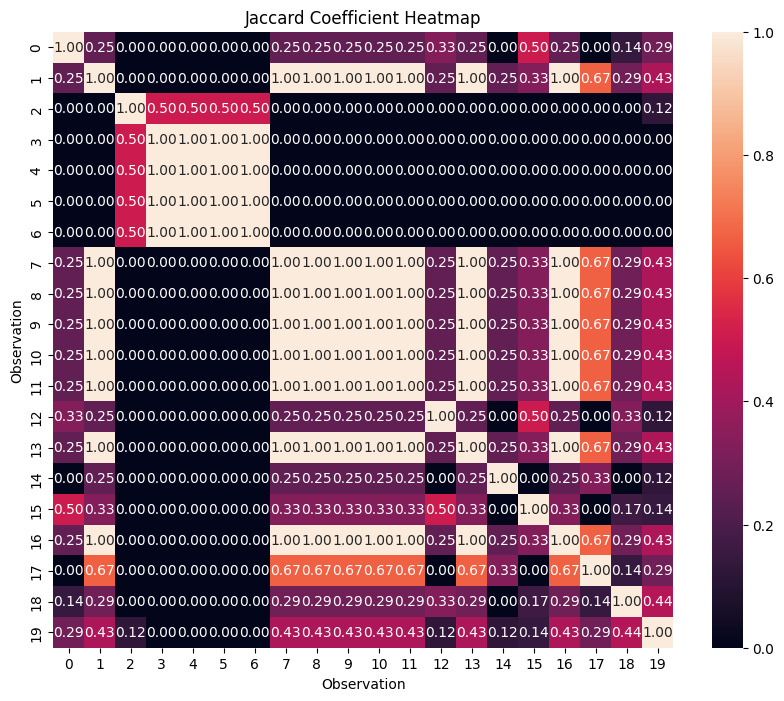

In [6]:
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(jc_matrix, annot=True, fmt=".2f")

plt.title("Jaccard Coefficient Heatmap")
plt.xlabel("Observation")
plt.ylabel("Observation")

plt.show()

SMC Heatmap

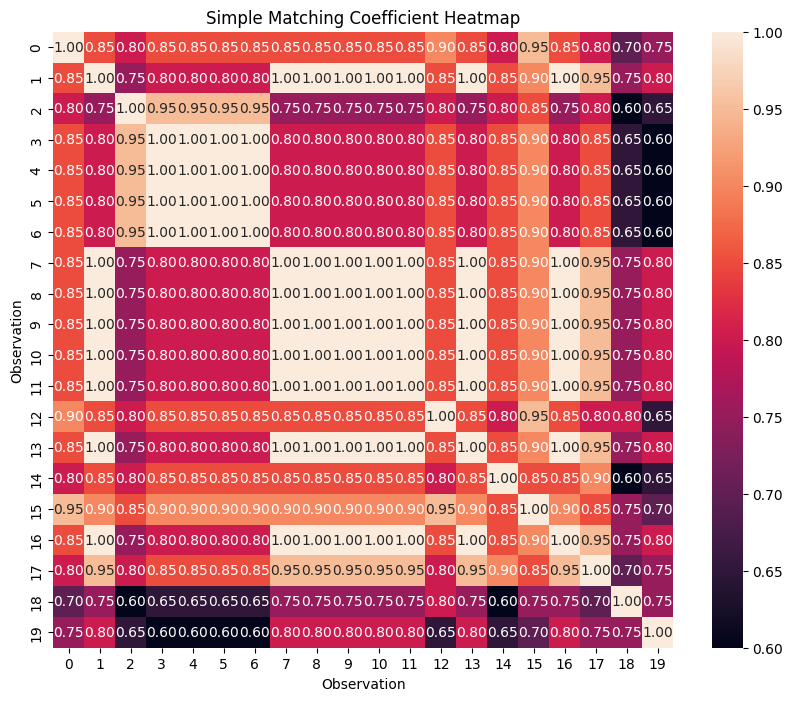

In [7]:
plt.figure(figsize=(10, 8))

sns.heatmap(smc_matrix, annot=True, fmt=".2f")

plt.title("Simple Matching Coefficient Heatmap")
plt.xlabel("Observation")
plt.ylabel("Observation")

plt.show()

cosine similarity heatmap

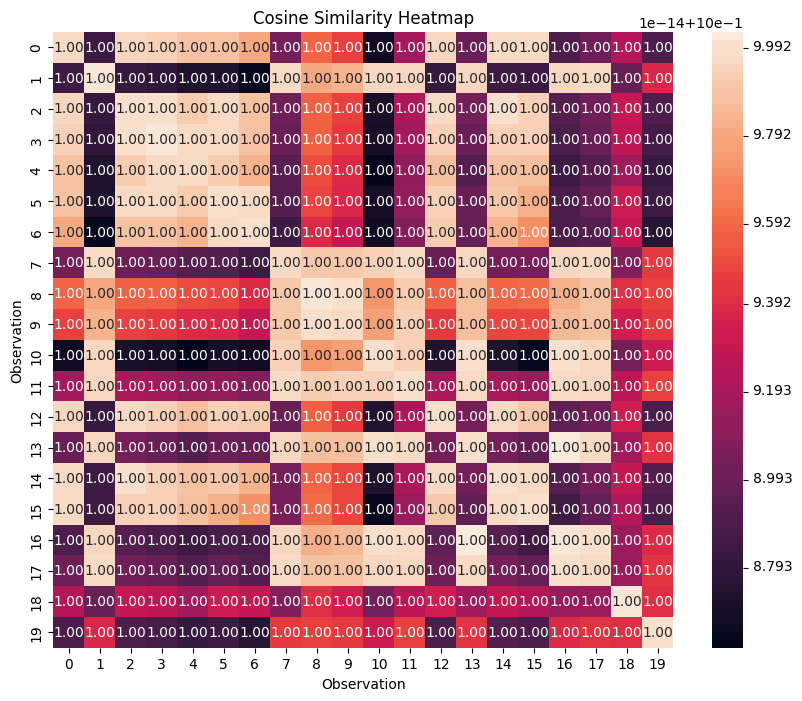

In [8]:
plt.figure(figsize=(10, 8))

sns.heatmap(cosine_matrix, annot=True, fmt=".2f")

plt.title("Cosine Similarity Heatmap")
plt.xlabel("Observation")
plt.ylabel("Observation")

plt.show()